In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[ 5.39230974,  0.57250094],
       [ 6.96048767,  0.22154309],
       [ 3.70056542, -0.05424334],
       ...,
       [ 5.03673607, -0.1333636 ],
       [ 3.57673331, -1.16407641],
       [ 6.29572175,  1.6293616 ]])

In [4]:
y

array([0, 0, 0, 0, 0, 1, 1, 1, 2, 0, 2, 2, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 2, 0, 2, 0, 0, 0, 1, 2, 2, 0, 0, 2, 1, 0, 0, 1, 1,
       1, 2, 1, 2, 0, 2, 0, 2, 1, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 0, 1, 2,
       0, 0, 0, 0, 2, 2, 2, 0, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 1, 0, 0, 0,
       2, 0, 2, 0, 1, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 2, 1, 1, 0, 0, 1, 2,
       2, 0, 1, 1, 0, 1, 1, 1, 2, 1, 1, 2, 0, 0, 2, 1, 2, 2, 1, 0, 2, 1,
       2, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 0, 2,
       1, 0, 0, 0, 2, 1, 0, 1, 1, 0, 0, 2, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 2, 2, 2, 2, 1, 0, 1, 1, 0, 0, 2, 0, 1, 0, 1, 1, 1, 2, 1, 2, 1,
       0, 2, 1, 0, 1, 1, 2, 2, 1, 0, 0, 0, 1, 0, 1, 2, 2, 1, 2, 1, 1, 0,
       2, 0, 0, 1, 1, 1, 0, 2, 1, 0, 1, 0, 1, 2, 2, 1, 0, 0, 0, 0, 2, 1,
       1, 2, 1, 0, 2, 2, 0, 1, 2, 2, 1, 0, 2, 2, 2, 1, 1, 2, 0, 2, 0, 2,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 2, 2, 1, 0, 1, 1, 2, 1, 0, 0, 0, 1, 0,
       0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 1,

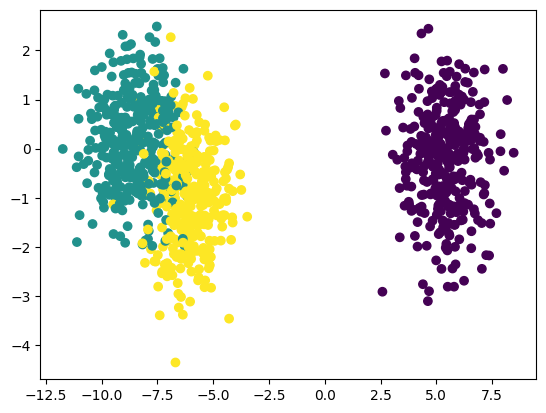

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [10]:
## standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [14]:
from sklearn.cluster import KMeans
## Elbow method

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
wcss

[1340.0000000000002,
 702.0683010320207,
 389.4665663693523,
 296.876823057941,
 185.80853307647223,
 159.49207006172028,
 134.11758261235596,
 105.43964910562855,
 88.8997982334288,
 77.16795102556895]

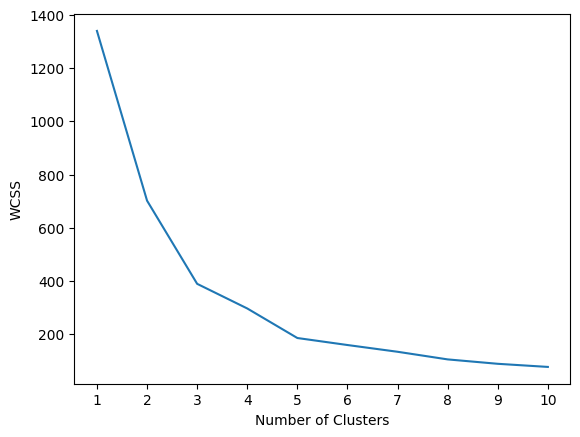

In [15]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(X_train_scaled)

array([0, 2, 2, 0, 1, 0, 1, 2, 2, 0, 1, 2, 1, 0, 2, 2, 2, 2, 2, 0, 0, 2,
       0, 1, 1, 2, 2, 1, 0, 2, 2, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 2,
       0, 2, 1, 1, 0, 1, 1, 2, 2, 2, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 2, 0,
       0, 2, 2, 1, 1, 2, 1, 0, 2, 0, 1, 0, 2, 1, 1, 2, 1, 1, 0, 0, 2, 1,
       2, 0, 1, 2, 1, 0, 2, 2, 2, 0, 2, 1, 1, 0, 0, 0, 0, 2, 1, 2, 1, 1,
       0, 2, 2, 0, 1, 1, 0, 0, 1, 2, 0, 2, 1, 1, 1, 2, 0, 1, 2, 0, 2, 0,
       1, 2, 0, 0, 1, 2, 2, 0, 1, 2, 1, 1, 0, 1, 2, 0, 0, 0, 2, 0, 0, 1,
       0, 2, 0, 0, 2, 0, 1, 0, 2, 1, 0, 2, 2, 1, 1, 0, 1, 2, 0, 2, 0, 0,
       0, 2, 2, 0, 2, 0, 2, 2, 0, 0, 1, 2, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2,
       2, 1, 0, 1, 2, 0, 0, 2, 2, 2, 2, 1, 1, 1, 1, 2, 0, 2, 1, 2, 2, 2,
       2, 0, 1, 0, 2, 1, 2, 1, 0, 1, 0, 1, 1, 1, 2, 2, 0, 2, 2, 1, 2, 2,
       2, 1, 2, 1, 0, 1, 1, 0, 2, 1, 0, 0, 1, 1, 0, 1, 2, 2, 1, 0, 2, 1,
       0, 0, 2, 1, 2, 2, 2, 2, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 2, 0, 1, 1, 1, 0, 2, 2,

In [18]:
y_pred=kmeans.predict(X_test_scaled)
y_pred

array([1, 1, 1, 0, 0, 2, 2, 2, 0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 2, 2, 1, 1, 2, 0, 2, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 0,
       1, 2, 1, 1, 1, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 2, 0, 2, 1, 1, 1, 0,
       0, 1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 2, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0,
       0, 1, 0, 2, 1, 0, 1, 1, 1, 2, 1, 2, 0, 2, 0, 2, 0, 1, 1, 0, 1, 2,
       2, 1, 2, 0, 1, 2, 0, 1, 1, 2, 0, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       0, 2, 1, 1, 0, 0, 2, 2, 0, 2, 1, 1, 2, 1, 0, 0, 2, 2, 1, 0, 2, 1,
       0, 0, 0, 2, 1, 0, 0, 0, 1, 2, 1, 0, 2, 2, 2, 0, 1, 2, 0, 2, 1, 0,
       2, 0, 1, 1, 0, 0, 0, 2, 0, 1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 0, 1,
       1, 1, 2, 0, 2, 2, 0, 2, 2, 2, 0, 1, 2, 0, 1, 0, 2, 0, 2, 0, 1, 2,
       0, 2, 1, 0, 2, 1, 2, 1, 1, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 2, 2, 1, 0, 0, 0, 2, 1, 0, 1, 2, 1, 1,
       2, 2, 1, 2, 0, 0, 1, 2, 2, 2, 0, 1, 2, 0, 1, 2, 2, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 2, 1, 0, 0, 1, 2, 0, 1, 0, 1, 2,

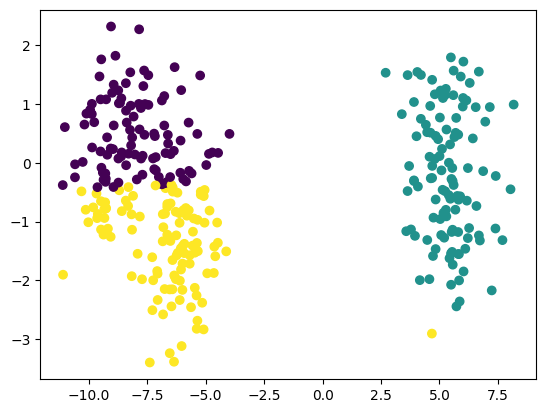

In [19]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [20]:
## validating the k value
## 1.kneelocator
!pip install kneed


[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
kl.elbow

np.int64(3)

In [25]:
## 2.Silhoutte score
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

silhouette_coefficients

[np.float64(0.3241804593960257),
 np.float64(0.5109161271042968),
 np.float64(0.4791353814989854),
 np.float64(0.4867422621240141),
 np.float64(0.45964979219241886),
 np.float64(0.4260730508387885),
 np.float64(0.42406960770835417),
 np.float64(0.41824988486054265),
 np.float64(0.4046965702295114)]

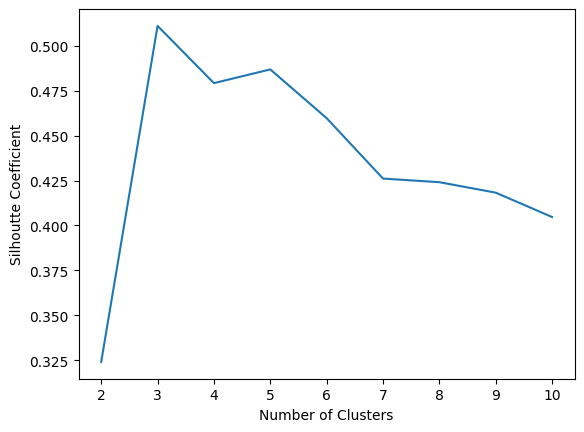

In [26]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coefficient")
plt.show()